# Starbucks Customer Review Sentiment Analysis

This section applies TextBlob and VADER sentiment analysis to Starbucks customer reviews. The aim is to compare how both sentiment tools perform on a dataset that contains more negative customer feedback than the Amazon dataset.

In [2]:
import pandas as pd

#Load Starbucks reviews dataset
file_path = "Starbucks-reviews_data.csv"
starbucks_df = pd.read_csv(file_path)

#Display first few rows
starbucks_df.head()

,name,location,Date,Rating,Review,Image_Links
0,Helen,"Wichita Falls, TX","Reviewed Sept. 13, 2023",5.0,Amber and LaDonna at the Starbucks on Southwes...,['No Images']
1,Courtney,"Apopka, FL","Reviewed July 16, 2023",5.0,** at the Starbucks by the fire station on 436...,['No Images']
2,Daynelle,"Cranberry Twp, PA","Reviewed July 5, 2023",5.0,I just wanted to go out of my way to recognize...,['https://media.consumeraffairs.com/files/cach...
3,Taylor,"Seattle, WA","Reviewed May 26, 2023",5.0,Me and my friend were at Starbucks and my card...,['No Images']
4,Tenessa,"Gresham, OR","Reviewed Jan. 22, 2023",5.0,I’m on this kick of drinking 5 cups of warm wa...,['https://media.consumeraffairs.com/files/cach...


## Dataset Overview

The Starbucks dataset contains customer reviews, ratings, locations, review dates, and image links. Unlike the Amazon dataset, this dataset includes a larger proportion of negative reviews, making it useful for comparing how TextBlob and VADER handle more varied sentiment.

In [3]:
#Displays the dataset information
print("Dataset Information")
print("-" * 50)
print(starbucks_df.info())

print("\nMissing Values")
print("-" * 50)
print(starbucks_df.isnull().sum())

print("\nSummary Statistics")
print("-" * 50)
print(starbucks_df.describe())

Dataset Information
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         850 non-null    object 
 1   location     850 non-null    object 
 2   Date         850 non-null    object 
 3   Rating       705 non-null    float64
 4   Review       850 non-null    object 
 5   Image_Links  850 non-null    object 
dtypes: float64(1), object(5)
memory usage: 40.0+ KB
None

Missing Values
--------------------------------------------------
name             0
location         0
Date             0
Rating         145
Review           0
Image_Links      0
dtype: int64

Summary Statistics
--------------------------------------------------
           Rating
count  705.000000
mean     1.870922
std      1.397672
min      1.000000
25%      1.000000
50%      1.000000
75%      2.000000
max      5.000000


The Starbucks dataset contains 850 reviews as well as 6 columns. The `Review` column has no missing values, meaning that sentiment analysis can be applied to all reviews. However, the `Rating` column has 145 missing values, so rating-based evaluation should only use rows where ratings are available.

The average rating is 1.87, with a median of 1.0, showing that this dataset is much more negative than the Amazon dataset.

## Text Cleaning and TextBlob Sentiment Analysis

The review text was cleaned before sentiment analysis by converting text to lowercase, removing punctuation, removing numerical values, and handling whitespace.

TextBlob was then used to calculate a sentiment polarity score for each review. The polarity score ranges from -1 for negative sentiment to +1 for positive sentiment.

In [4]:
from textblob import TextBlob
import re

#Function to clean the review text
def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


#Applying a cleaning function to the Starbucks review text
starbucks_df["clean_review"] = starbucks_df["Review"].apply(clean_text)


#Function to calculate the TextBlob polarity
def get_textblob_score(text):
    return TextBlob(text).sentiment.polarity


#Applying TextBlob sentiment analysis
starbucks_df["textblob_score"] = starbucks_df["clean_review"].apply(get_textblob_score)


#Displaying the results
starbucks_df[["Review", "clean_review", "textblob_score"]].head()

,Review,clean_review,textblob_score
0,Amber and LaDonna at the Starbucks on Southwes...,amber and ladonna at the starbucks on southwes...,0.340816
1,** at the Starbucks by the fire station on 436...,at the starbucks by the fire station on in alt...,0.284848
2,I just wanted to go out of my way to recognize...,i just wanted to go out of my way to recognize...,-0.071429
3,Me and my friend were at Starbucks and my card...,me and my friend were at starbucks and my card...,0.263750
4,I’m on this kick of drinking 5 cups of warm wa...,im on this kick of drinking cups of warm water...,0.356905


## Descriptive Statistics for TextBlob Scores

Summary statistics were calculated to understand the distribution of TextBlob sentiment scores across the Starbucks reviews.

In [5]:
print("Descriptive Statistics for TextBlob Scores")
print("-" * 50)
print(starbucks_df["textblob_score"].describe())

Descriptive Statistics for TextBlob Scores
--------------------------------------------------
count    850.000000
mean       0.031339
std        0.213679
min       -0.800000
25%       -0.083036
50%        0.006050
75%        0.154083
max        0.825000
Name: textblob_score, dtype: float64


The TextBlob sentiment distribution for the Starbucks reviews were far more balanced than the Amazon dataset. The mean sentiment score was close to neutral at 0.031, suggesting that customer opinions were mixed overall.

Unlike the Amazon dataset, which had a large amount of positive reviews, the Starbucks dataset contained a wider spread of negative and positive sentiment values.

## Visualisation of TextBlob Sentiment Scores

A histogram and scatter plot were generated to visualise the distribution of sentiment polarity scores and investigate the relationship between customer ratings and textual sentiment.

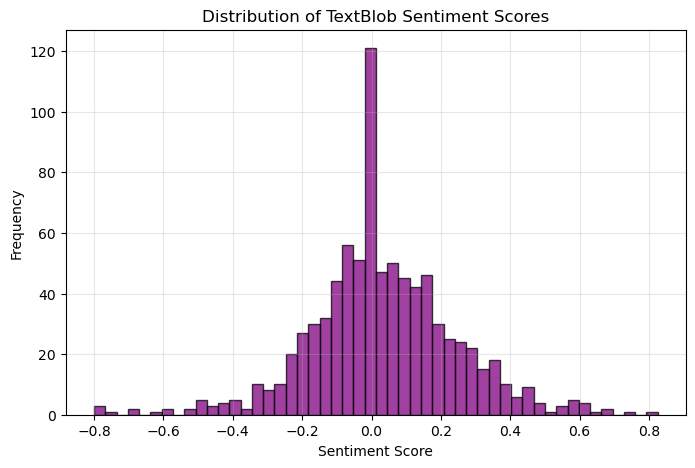

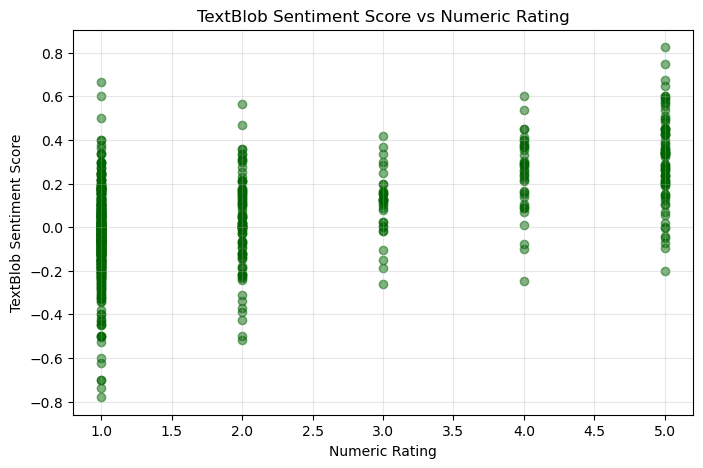

In [17]:
import matplotlib.pyplot as plt

#Histogram of TextBlob sentiment scores
plt.figure(figsize=(8, 5))

plt.hist(
    starbucks_df["textblob_score"],
    bins=50,
    alpha=0.75,
    color="purple",
    edgecolor="black")

plt.title("Distribution of TextBlob Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()


#Convert ratings to numeric
starbucks_df["numeric_rating"] = pd.to_numeric(
    starbucks_df["Rating"],
    errors="coerce")

#Scatter plot
plt.figure(figsize=(8, 5))

plt.scatter(
    starbucks_df["numeric_rating"],
    starbucks_df["textblob_score"],
    alpha=0.5,
    color="darkgreen")
plt.title("TextBlob Sentiment Score vs Numeric Rating")
plt.xlabel("Numeric Rating")
plt.ylabel("TextBlob Sentiment Score")
plt.grid(alpha=0.3)
plt.savefig("images/starbucks_textblob_rating_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

## TextBlob Results Interpretation

The TextBlob sentiment scores for the Starbucks reviews show a much more balanced distribution than the Amazon dataset. The histogram is centred close to 0, with the mean sentiment score around 0.031 and the median around 0.006. This suggests that the overall sentiment is close to neutral, rather than strongly positive or negative.

The distribution also spreads into both negative and positive values, with scores ranging from approximately -0.8 to 0.825. This indicates that the Starbucks dataset contains a wider variety of customer opinions, including strongly negative reviews, neutral comments, and positive feedback.

The scatter plot that compares numeric ratings with TextBlob sentiment scores shows a general upward trend. Reviews with higher ratings tend to have more positive sentiment scores, while lower rated reviews show more negative and mixed sentiment values. Some low-rated reviews still contain positive wording, and some higher-rated reviews contain neutral/mixed language.

Overall, the results suggest that TextBlob captures broad sentiment patterns in the Starbucks reviews, but customer ratings and written review sentiment do not always align.

## VADER Sentiment Analysis

VADER (Valence Aware Dictionary and sEntiment Reasoner) was applied as a second sentiment analysis approach to compare against TextBlob.

VADER is specifically designed for social as well as review-style text and can capture emotional intensity to a greater detail, punctuation and informal language patterns commonly found in customer feedback.

In [9]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

#Download VADER lexicon
nltk.download("vader_lexicon")

#Initialise VADER sentiment analyser
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Amaan\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [10]:
#Function to calculate VADER compound sentiment score
def get_vader_score(text):
    if not isinstance(text, str):
        return 0
    
    return sia.polarity_scores(text)["compound"]


#Applying VADER sentiment analysis
starbucks_df["vader_score"] = starbucks_df["clean_review"].apply(get_vader_score)


#Display the comparison
starbucks_df[[
    "clean_review",
    "textblob_score",
    "vader_score"]].head()

,clean_review,textblob_score,vader_score
0,amber and ladonna at the starbucks on southwes...,0.340816,0.8991
1,at the starbucks by the fire station on in alt...,0.284848,0.7344
2,i just wanted to go out of my way to recognize...,-0.071429,0.4215
3,me and my friend were at starbucks and my card...,0.263750,0.9232
4,im on this kick of drinking cups of warm water...,0.356905,0.9793


In [11]:
print("Descriptive Statistics for VADER Scores")
print("-" * 50)

print(starbucks_df["vader_score"].describe())

Descriptive Statistics for VADER Scores
--------------------------------------------------
count    850.000000
mean      -0.002738
std        0.674079
min       -0.987900
25%       -0.647325
50%       -0.102700
75%        0.706825
max        0.993800
Name: vader_score, dtype: float64


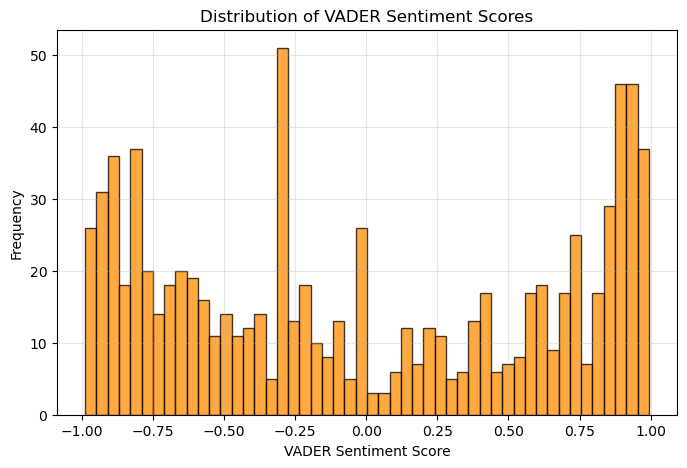

In [12]:
plt.figure(figsize=(8, 5))
#Histogram of Vader Sentiment Scores
plt.hist(
    starbucks_df["vader_score"],
    bins=50,
    alpha=0.75,
    color="darkorange",
    edgecolor="black")

plt.title("Distribution of VADER Sentiment Scores")
plt.xlabel("VADER Sentiment Score")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

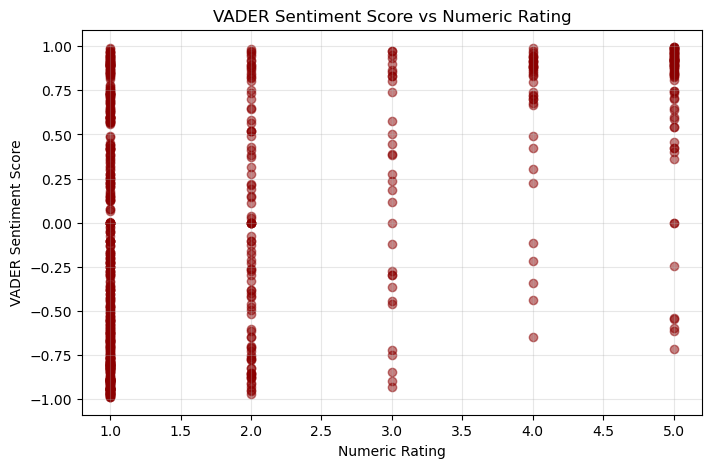

In [13]:
plt.figure(figsize=(8, 5))
#Scatter of Sentiment scores and numeric ratings using VADER
plt.scatter(
    starbucks_df["numeric_rating"],
    starbucks_df["vader_score"],
    alpha=0.5,
    color="darkred")

plt.title("VADER Sentiment Score vs Numeric Rating")
plt.xlabel("Numeric Rating")
plt.ylabel("VADER Sentiment Score")
plt.grid(alpha=0.3)
plt.show()

In [14]:
#Compare the correlations with ratings
textblob_corr = starbucks_df["numeric_rating"].corr(
    starbucks_df["textblob_score"])

vader_corr = starbucks_df["numeric_rating"].corr(
    starbucks_df["vader_score"])

print("Correlation Comparison")
print("-" * 50)

print(f"TextBlob correlation: {textblob_corr:.4f}")
print(f"VADER correlation:    {vader_corr:.4f}")

Correlation Comparison
--------------------------------------------------
TextBlob correlation: 0.5409
VADER correlation:    0.4546


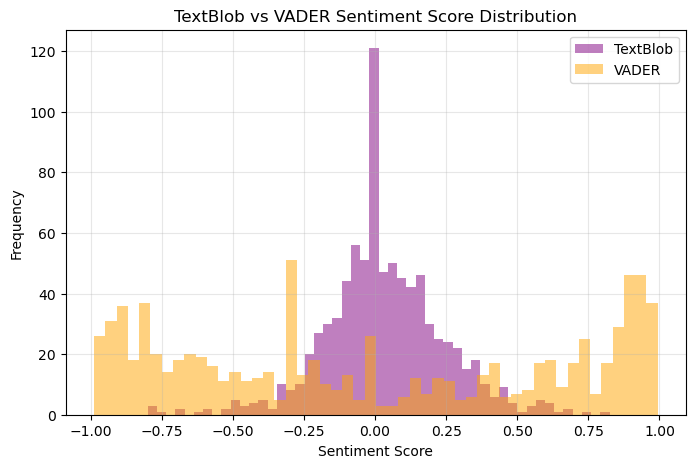

In [16]:
plt.figure(figsize=(8, 5))
#Comparing the histogram distributions with dark orange being the overlap of both textblob and Vader scores
plt.hist(
    starbucks_df["textblob_score"],
    bins=50,
    alpha=0.5,
    label="TextBlob",
    color="purple")

plt.hist(
    starbucks_df["vader_score"],
    bins=50,
    alpha=0.5,
    label="VADER",
    color="orange")

plt.title("TextBlob vs VADER Sentiment Score Distribution")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("images/starbucks_textblob_vs_vader_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## VADER Results Interpretation

The VADER sentiment scores show a much wider spread than the TextBlob scores. The mean VADER score was approximately -0.003, which is close to neutral, but the standard deviation was much larger at 0.674. This shows that VADER classified many reviews as strongly positive or strongly negative.

The VADER histogram shows peaks near both negative and positive extremes. This suggests that VADER is more sensitive to emotional intensity in customer review text compared with TextBlob, which produced a higher nconcentrated distribution around neutral sentiment.

The scatter plot comparing VADER scores with numeric ratings shows a general trend where higher ratings are associated with more positive VADER scores. 
The correlation comparison showed that TextBlob had a stronger correlation with numeric ratings, with a correlation of 0.5409 compared with VADER's 0.4546. This suggests that TextBlob aligned slightly more closely with the star ratings in this dataset, while VADER captured stronger sentiment intensity across the review text.

Overall, VADER provides a useful comparison because it highlights more extreme sentiment patterns and TextBlob gives a smoother and more moderate sentiment distribution.